In [1]:
import librosa
import numpy as np
import matplotlib.pyplot as plt

def segment_audio(y, sr, segment_seconds=3):
    seg_len = int(segment_seconds * sr)
    n_segments = len(y) // seg_len

    segments = np.array([
        y[i*seg_len:(i+1)*seg_len]
        for i in range(n_segments)
    ])

    return segments  # shape = (n_segments, 66150)


In [2]:
def mfcc_3s(segment, sr=22050):
    mfcc = librosa.feature.mfcc(
        y=segment,
        sr=sr,
        n_fft=2048,
        hop_length=512,
        n_mfcc=13,
        n_mels=1024,
        window="hamming",
        
    )
    print('')
    print('mfcc.shape (Note: ):')
    print(mfcc.shape)
    return mfcc.T       # final shape: (130, 13)


In [3]:
def compute_mfcc_segments(segments, sr=22050):
    mfcc_list = []
    for seg in segments:
        mfcc = mfcc_3s(seg, sr)  # shape (130, 13)
        mfcc_list.append(mfcc)
    return np.array(mfcc_list)   # shape (n_segments, 130, 13)


In [4]:
def process_file(file_path, sr=22050):
    # Load audio
    y, sr = librosa.load(file_path, sr=sr)
    
    # Split into 3-second fixed windows
    segments = segment_audio(y, sr)
    
    # Compute MFCC for each 3s segment
    mfccs = mfcc_3s(segments, sr)
    
    return mfccs


In [5]:
dataset_folder = "./dataverse_files"
OWN_path = "./dataverse_files/OWN"
file_name = "0001.mp3"
file_path = f"{OWN_path}/{file_name}"
mfccs = process_file(file_path)
print(mfccs.shape)  # (n_segments, 130, 13)



mfcc.shape (Note: ):
(10, 13, 130)
(130, 13, 10)


a:\6 Kod\KTH-kurser\DLFK HT25\dl_music_label_swapping\time_sig_replication\venv_time_sig_replication\lib\site-packages\librosa\feature\spectral.py:2148: UserWarning: Empty filters detected in mel frequency basis. Some channels will produce empty responses. Try increasing your sampling rate (and fmax) or reducing n_mels.
  mel_basis = filters.mel(sr=sr, n_fft=n_fft, **kwargs)


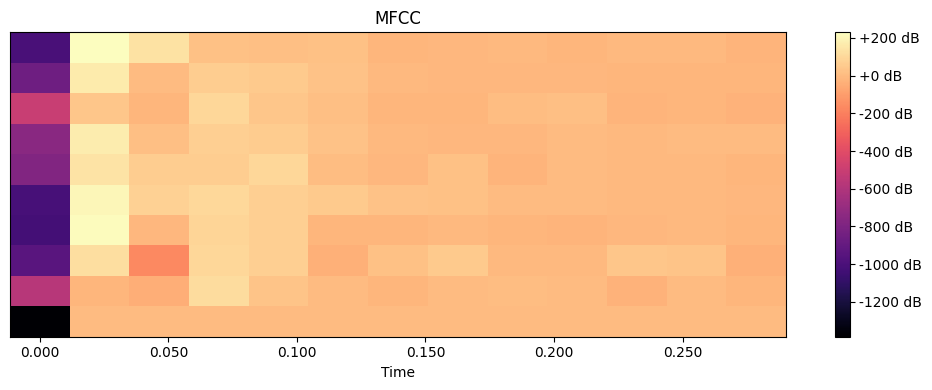

In [6]:
import librosa.display
import matplotlib.pyplot as plt

def plot_mfcc(mfcc, sr=22050, hop_length=512):
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(
        mfcc,
        x_axis='time',
        sr=sr,
        hop_length=hop_length,
        cmap='magma'
    )
    plt.colorbar(format="%+2.f dB")
    plt.title("MFCC")
    plt.tight_layout()
    plt.show()
    
plot_mfcc(mfccs[0].T)  # Plot MFCC of the first segment




## Perform actual feature extraction and save new files

In [7]:
def one_hot_encode(label, label_map):
    y = np.zeros(len(label_map), dtype=np.float32)
    y[label_map[label]] = 1.0
    return y


In [8]:
label_map = {"three": 0, "four": 1, "five": 2, "seven": 3}


In [9]:
import os
import csv
import numpy as np

def build_split(csv_path, base_audio_folder, output_npz, sr=22050, label_map={"three": 0, "four": 1, "five": 2, "seven": 3}):
    X_list = []
    y_list = []
    supported_extensions = ['', '.wav', '.mp3', '.flac', '.ogg', '.m4a']

    with open(csv_path, 'r', newline='', encoding='utf-8') as f:
        reader = csv.DictReader(f)
        for row in reader:
            audio_rel_path = row['filename'].strip().replace("\\", "/").lstrip("/")
            base_path = os.path.join(base_audio_folder, audio_rel_path)
            base_path = os.path.normpath(base_path)
            
            root_path, _ = os.path.splitext(base_path)
            file_path = base_path
            found = False

            for ext in supported_extensions:
                potential_path = root_path + ext
                if os.path.exists(potential_path):
                    file_path = potential_path
                    found = True
                    break
            
            if not found:
                raise FileNotFoundError(f"Audio file not found: {root_path} (Checked exts: {supported_extensions})")

            mfcc_segments = process_file(file_path, sr=sr)
            
            # Input shape: (Time, MFCC, Segments) e.g., (130, 13, 10)
            # New shape:   (Segments, Time, MFCC) e.g., (10, 130, 13)
            mfcc_segments = np.moveaxis(mfcc_segments, -1, 0)
            
            y_single = one_hot_encode(row['label'], label_map)

            for segment in mfcc_segments:
                X_list.append(segment)
                y_list.append(y_single)

    X = np.array(X_list, dtype=np.float32)
    y = np.stack(y_list, axis=0)

    np.savez_compressed(output_npz, X=X, y=y)
    print("Saved", output_npz)
    print("Final X shape:", X.shape)
    print("Final y shape:", y.shape)

In [13]:
#build_split("./dataverse_files/data_train_4_classes.csv", dataset_folder, "train_data.npz")
#build_split("./dataverse_files/data_val_4_classes.csv", dataset_folder, "val_data.npz")
build_split("./dataverse_files/data_test_4_classes.csv",  dataset_folder, "test_data.npz")


a:\6 Kod\KTH-kurser\DLFK HT25\dl_music_label_swapping\time_sig_replication\venv_time_sig_replication\lib\site-packages\librosa\feature\spectral.py:2148: UserWarning: Empty filters detected in mel frequency basis. Some channels will produce empty responses. Try increasing your sampling rate (and fmax) or reducing n_mels.
  mel_basis = filters.mel(sr=sr, n_fft=n_fft, **kwargs)



mfcc.shape (Note: ):
(10, 13, 130)

mfcc.shape (Note: ):
(10, 13, 130)

mfcc.shape (Note: ):
(9, 13, 130)

mfcc.shape (Note: ):
(10, 13, 130)

mfcc.shape (Note: ):
(10, 13, 130)

mfcc.shape (Note: ):
(10, 13, 130)

mfcc.shape (Note: ):
(9, 13, 130)

mfcc.shape (Note: ):
(10, 13, 130)

mfcc.shape (Note: ):
(10, 13, 130)

mfcc.shape (Note: ):
(9, 13, 130)

mfcc.shape (Note: ):
(9, 13, 130)

mfcc.shape (Note: ):
(9, 13, 130)

mfcc.shape (Note: ):
(10, 13, 130)

mfcc.shape (Note: ):
(10, 13, 130)

mfcc.shape (Note: ):
(10, 13, 130)

mfcc.shape (Note: ):
(10, 13, 130)

mfcc.shape (Note: ):
(9, 13, 130)

mfcc.shape (Note: ):
(9, 13, 130)

mfcc.shape (Note: ):
(9, 13, 130)

mfcc.shape (Note: ):
(10, 13, 130)

mfcc.shape (Note: ):
(9, 13, 130)

mfcc.shape (Note: ):
(10, 13, 130)

mfcc.shape (Note: ):
(10, 13, 130)

mfcc.shape (Note: ):
(10, 13, 130)

mfcc.shape (Note: ):
(10, 13, 130)

mfcc.shape (Note: ):
(10, 13, 130)

mfcc.shape (Note: ):
(9, 13, 130)

mfcc.shape (Note: ):
(9, 13, 130)

mf

In [11]:
import os
print(os.path.exists("./dataverse_files/MAG/00247"))
print(os.path.exists("./dataverse_files\\MAG\\00247"))
print(os.path.exists("./dataverse_files/MAG/00247.mp3"))

False
False
True


In [12]:
import os
print("CWD:", os.getcwd())


CWD: a:\6 Kod\KTH-kurser\DLFK HT25\dl_music_label_swapping\time_sig_replication
